In [27]:
import pandas as pd
import seaborn as sns

items_df = pd.read_csv("../data/items.csv")
orders_df = pd.read_csv("../data/orders.csv")
users_df = pd.read_csv("../data/users.csv")
df = orders_df.merge(users_df, on="user_id", how="left").merge(items_df, on="item_id", how="left")

print(f'Размер датасета - {df.shape}')

print(f'Первые 5 строк датасета')
display(df.head())

print('Основная информация о типах и качестве заполнения данных')
df.info()

print('Требуется приведение дат к соответствующем типу, пропусков нет')
df['order_date'] = pd.to_datetime(df['order_date'], errors="coerce")
df['registration_date'] = pd.to_datetime(df['registration_date'], errors="coerce")
print('Приведение типов выполнено')

Размер датасета - (40, 14)
Первые 5 строк датасета


,order_id,user_id,order_date,item_id,quantity,price_per_unit,user_name,registration_date,city,user_segment,item_name,category,supplier,base_price
0,1001,1,2024-02-01 10:15:00,101,2,1499.99,Анна Смирнова,2023-05-10,Москва,regular,Смартфон Xiaomi Redmi,Электроника,"ООО ""ТехноСнаб""",14999.0
1,1002,2,2024-02-01 11:30:00,102,1,2999.00,Дмитрий Иванов,2023-08-22,Санкт-Петербург,vip,Ноутбук ASUS VivoBook,Электроника,"ООО ""Компьютерный Мир""",49999.0
2,1003,3,2024-02-01 14:45:00,103,3,499.50,Елена Петрова,2024-01-15,Казань,new,Футболка хлопковая,Одежда,"ООО ""ТекстильПро""",999.0
3,1004,1,2024-02-01 16:20:00,104,1,3499.00,Анна Смирнова,2023-05-10,Москва,regular,Беспроводные наушники Sony,Электроника,"ООО ""ТехноСнаб""",7990.0
4,1005,4,2024-02-02 09:15:00,101,1,1499.99,Иван Козлов,2023-11-03,Екатеринбург,regular,Смартфон Xiaomi Redmi,Электроника,"ООО ""ТехноСнаб""",14999.0


Основная информация о типах и качестве заполнения данных
<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           40 non-null     int64  
 1   user_id            40 non-null     int64  
 2   order_date         40 non-null     str    
 3   item_id            40 non-null     int64  
 4   quantity           40 non-null     int64  
 5   price_per_unit     40 non-null     float64
 6   user_name          40 non-null     str    
 7   registration_date  40 non-null     str    
 8   city               40 non-null     str    
 9   user_segment       40 non-null     str    
 10  item_name          40 non-null     str    
 11  category           40 non-null     str    
 12  supplier           40 non-null     str    
 13  base_price         40 non-null     float64
dtypes: float64(2), int64(4), str(8)
memory usage: 10.9 KB
Требуется приведение дат

In [28]:
print('Уникальные значения категорий')
print('=====')
print(f'Столбец city - {df['city'].unique().tolist()}')
print('=====')
print(f'Столбец user_segment - {df['user_segment'].unique().tolist()}')
print('=====')
print(f'Столбец item_name - {df['item_name'].unique().tolist()}')
print('=====')
print(f'Столбец category - {df['category'].unique().tolist()}')
print('=====')
print(f'Столбец supplier - {df['supplier'].unique().tolist()}')
print('=====')
print('Замены не требуются')

Уникальные значения категорий
=====
Столбец city - ['Москва', 'Санкт-Петербург', 'Казань', 'Екатеринбург', 'Новосибирск', 'Краснодар']
=====
Столбец user_segment - ['regular', 'vip', 'new']
=====
Столбец item_name - ['Смартфон Xiaomi Redmi', 'Ноутбук ASUS VivoBook', 'Футболка хлопковая', 'Беспроводные наушники Sony', 'Книга "Python для анализа данных"', 'Кроссовки беговые Nike', "Кофеварка De'Longhi", 'Смарт-часы Apple Watch', "Джинсы Levi's", 'Игровая приставка PlayStation', 'Набор кухонных ножей', 'Сумка рюкзак Herschel', 'Скейтборд', 'Соковыжималка Philips', 'Кроссовки Adidas', 'Толстовка утепленная', 'Блендер Bosch', 'Настольная игра Монополия', 'Шапка зимняя', 'Фитнес-браслет Xiaomi']
=====
Столбец category - ['Электроника', 'Одежда', 'Книги', 'Обувь', 'Бытовая техника', 'Товары для дома', 'Аксессуары', 'Спорттовары', 'Игры']
=====
Столбец supplier - ['ООО "ТехноСнаб"', 'ООО "Компьютерный Мир"', 'ООО "ТекстильПро"', 'ИД "Питер"', 'АО "СпортИмпорт"', 'ООО "Домашний Уют"', 'ООО "Сти

,order_id,user_id,order_date,item_id,quantity,price_per_unit,registration_date,base_price
count,40.000000,40.000000,40,40.000000,40.000000,40.000000,40,40.000000
mean,1020.500000,11.125000,2024-02-05 20:52:15,108.275000,1.500000,1980.361500,2023-09-28 09:00:00,14768.225000
min,1001.000000,1.000000,2024-02-01 10:15:00,101.000000,1.000000,299.000000,2023-04-14 00:00:00,999.000000
25%,1010.750000,5.750000,2024-02-03 12:35:00,103.000000,1.000000,799.000000,2023-07-05 00:00:00,2990.000000
50%,1020.500000,10.500000,2024-02-05 17:07:30,107.500000,1.000000,1394.500000,2023-09-27 12:00:00,8490.000000
75%,1030.250000,15.250000,2024-02-08 10:48:45,112.250000,2.000000,2999.000000,2024-01-11 06:00:00,14999.000000
max,1040.000000,25.000000,2024-02-10 15:30:00,120.000000,4.000000,5990.000000,2024-02-08 00:00:00,49999.000000
std,11.690452,6.820736,NaN,5.652263,0.784465,1606.699419,NaN,16844.726653


Отрицательных значений нет, есть подозрение на выбросы у цен (слишком большое максимальное значение)
На боксплотах явных выбросов в виде точек нет


<Axes: xlabel='base_price', ylabel='category'>

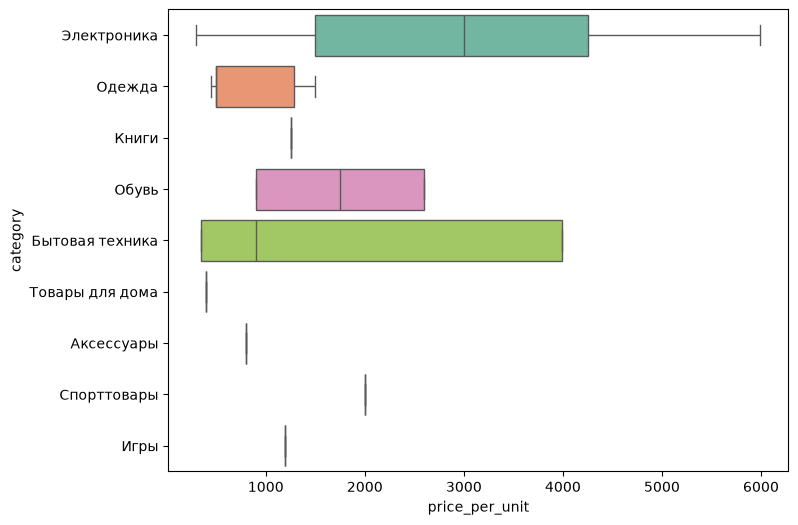

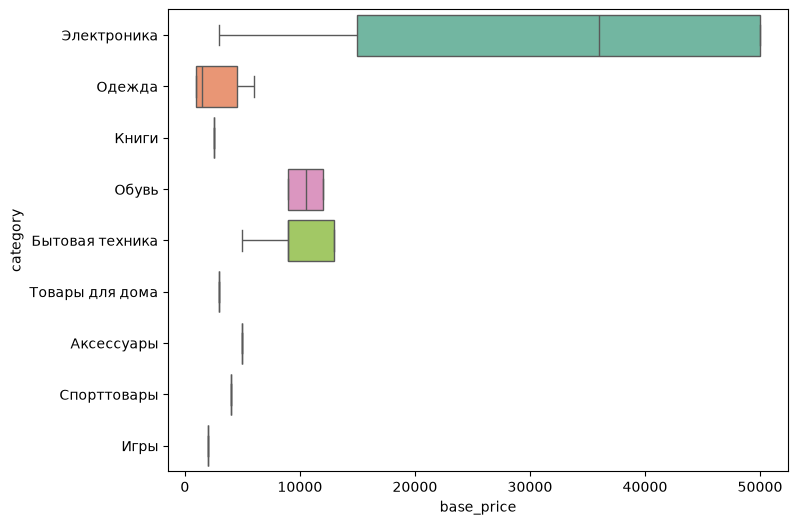

In [29]:
display(df.describe())
print('Отрицательных значений нет, есть подозрение на выбросы у цен (слишком большое максимальное значение)')
print('На боксплотах явных выбросов в виде точек нет. Дополнительная очистка не требуется')

plt.figure(figsize=(8, 6))
sns.boxplot(x="price_per_unit",y='category', hue = 'category', data=df, palette="Set2")
plt.figure(figsize=(8, 6))
sns.boxplot(x="base_price",y='category', hue = 'category', data=df, palette="Set2")